# Animal Ontology Analysis

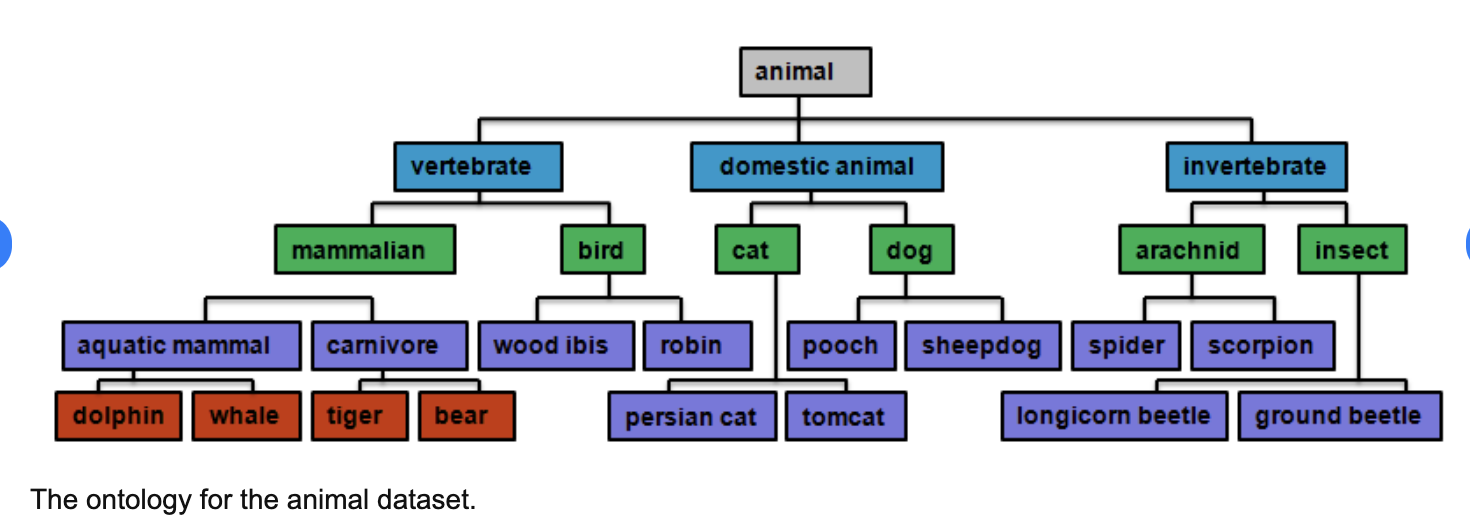

## Flow
1. Dataset Collection:
  - Collect word lists related to mammals (target class) and reptiles (control/comparison class) from resources like Hugging Face or WordNet.
 - These categories will serve as the basis for analyzing class-specific clustering and hierarchy alignment.

2. Embedding:
  - Use a sentence transformer model to compute embeddings for each word.

3. Clustering
  - Apply KMeans clustering and determine optimal k using the elbow method.

4. Visualization:
  - Visualize embeddings and cluster centers using PCA (or optionally t-SNE).
  - Annotate representative words and draw ontology hierarchy arrows.

5. Cosine Similarity Analysis:
  - Compare cluster center similarity to each word and its representative.
  - Analyze cluster cohesion and alignment.

6. Hierarchy Alignment:
  - Build a hierarchy (e.g., animal → mammal → primates) and measure cosine similarity between parent and child category centers.
  - Check if hierarchical relationships are reflected in embedding space.

<!-- 1. 단어 데이터셋 구성
  - mammal, reptile 관련 단어 리스트를 Hugging Face나 WordNet, ConceptNet 등을 통해 확보.
  - 클래스별 서브클래스 구성 → ontology 계층을 미리 구성 가능.

2. Embedding & Clustering
  - 각 단어에 대해 sentence-transformers 혹은 word2vec, GloVe, fastText로 임베딩.
  - K-means clustering + elbow method로 군집 수 결정.

3. PCA or t-SNE 시각화
  - 2D로 줄인 후 cluster center + subclass center 시각화.
  - 화살표로 계층적 관계 표현 (mammal → primate, primate → chimpanzee 등).

4. Cosine Similarity 분석
  - 중심 벡터 간, 단어-클러스터 중심 간, 상하위 개념 간 similarity 측정.

5. Hierarchy Alignment Analysis
  - ontology 상 계층 구조와 실제 cluster 구조가 얼마나 일치하는지 분석 (alignment).
  - 예: mammal이 primate, canine, feline 등과 가까운지. -->

---

## Ontology (Further)
using words

1. 3 clusters, 30 words in each cluster
    
    ⇒ 90 words cluster (assign 3 groups)
    
    optimal_k = 3, kmeans clustering of 90 words (classify)
    
2. find the accuracy & best clustering method

  choose particular group (cluster, animal types) → go to same analysis of the below level

In [1]:
!pip install kneed

In [43]:
from nltk.corpus import wordnet as wn
import nltk
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
import seaborn as sns
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cosine
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import networkx as nx

In [3]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

### 1. Dataset

In [4]:
def get_hyponyms(synset, depth=1, current_depth=0):
    result = []
    if current_depth < depth:
        for hyponym in synset.hyponyms():
            result.append(hyponym)
            result.extend(get_hyponyms(hyponym, depth, current_depth + 1))
    return result

In [5]:
def get_all_lemmas(synset_list):
    lemmas = []
    for synset in synset_list:
        lemmas.extend([lemma.name().replace('_', ' ') for lemma in synset.lemmas()])
    return list(set(lemmas))  # prevent duplicates

In [6]:
# vertebrate, invertebrate

vertebrate_synset = wn.synset('vertebrate.n.01')
invertebrate_synset = wn.synset('invertebrate.n.01')

In [7]:
# domestic animal
domestic_animal_synsets = []
animal_synset = wn.synset('animal.n.01')

for animal in get_hyponyms(animal_synset, depth=2):
    if any('domestic' in lemma.name() for lemma in animal.lemmas()):
        domestic_animal_synsets.append(animal)
    elif any(keyword in lemma.name() for lemma in animal.lemmas()
             for keyword in ['pet', 'domesticated']):
        domestic_animal_synsets.append(animal)

common_domestic = ['dog.n.01', 'cat.n.01', 'horse.n.01', 'cow.n.01',
                   'sheep.n.01', 'chicken.n.01', 'pig.n.01', 'goat.n.01']
for animal in common_domestic:
    try:
        domestic_animal_synsets.append(wn.synset(animal))
    except:
        pass

In [8]:
# subwords

vertebrate_hyponyms = get_hyponyms(vertebrate_synset, depth=2)
invertebrate_hyponyms = get_hyponyms(invertebrate_synset, depth=2)
domestic_animal_hyponyms = []
for synset in domestic_animal_synsets:
    domestic_animal_hyponyms.extend(get_hyponyms(synset, depth=1))
domestic_animal_hyponyms.extend(domestic_animal_synsets)

In [9]:
# extract lemmas
vertebrate_words = get_all_lemmas([vertebrate_synset] + vertebrate_hyponyms)
invertebrate_words = get_all_lemmas([invertebrate_synset] + invertebrate_hyponyms)
domestic_animal_words = get_all_lemmas(domestic_animal_hyponyms)

In [10]:
print(f"Vertebrates ({len(vertebrate_words)}): {vertebrate_words[:20]}...")
print(f"Invertebrates ({len(invertebrate_words)}): {invertebrate_words[:20]}...")
print(f"Domestic Animals ({len(domestic_animal_words)}): {domestic_animal_words}...")

Vertebrates (95): ['twitterer', 'trogon', 'bird of passage', 'bird of prey', 'frog', 'gnathostome', 'caudate', 'dickybird', 'fish', 'protoavis', 'Ibero-mesornis', 'dicky-bird', 'archaeornis', 'vertebrate', 'toad frog', 'teras', 'tusker', 'ratite bird', 'Sinornis', 'placental mammal']...
Invertebrates (123): ['millipede', 'nemertean', 'nematode worm', 'pentastomid', "Venus's girdle", 'chaetognath', 'brittle star', 'sea urchin', 'roundworm', 'sea gooseberry', 'parasitic worm', 'basket fish', 'brittle-star', 'centipede', 'Cestum veneris', 'arachnoid', 'millepede', 'platyctenean', 'woodborer', 'bryozoan']...
Domestic Animals (163): ['ewe', 'head', 'carriage dog', 'mongrel', 'mare', 'tortoiseshell-cat', 'bangtail', 'grunter', 'pet', 'feeder', 'toy dog', 'palomino', 'Burmese cat', 'pig', 'workhorse', 'mouser', 'domestic cat', 'Siamese', 'Equus caballus', 'protohippus', 'cat', 'tortoiseshell', 'wild horse', 'Capra hircus', 'mesohippus', 'porker', 'Leonberg', 'cow', 'squealer', 'dalmatian', 'k

In [11]:
# save dataset
with open('vertebrates.txt', 'w') as f:
    for word in vertebrate_words:
        f.write(f"{word}\n")

with open('invertebrates.txt', 'w') as f:
    for word in invertebrate_words:
        f.write(f"{word}\n")

with open('domestic_animals.txt', 'w') as f:
    for word in domestic_animal_words:
        f.write(f"{word}\n")

In [12]:
# entire dataset
with open('animal_dataset.csv', 'w') as f:
    f.write("word,category\n")
    for word in vertebrate_words:
        f.write(f"{word},vertebrate\n")
    for word in invertebrate_words:
        f.write(f"{word},invertebrate\n")
    for word in domestic_animal_words:
        f.write(f"{word},domestic_animal\n")

### Load Dataset
- after constructing dataset

In [13]:
df = pd.read_csv('/content/animal_dataset.csv')

In [16]:
print(df['category'].value_counts())

category
domestic_animal    163
invertebrate       123
vertebrate          95
Name: count, dtype: int64


In [21]:
print(df.head())
print(len(df))

              word    category
0        twitterer  vertebrate
1           trogon  vertebrate
2  bird of passage  vertebrate
3     bird of prey  vertebrate
4             frog  vertebrate
381


### 2. Embedding

In [17]:
# model

model_name = "all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)
print(model.eval())

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


In [30]:
embeddings = {}
for word in df['word']:
    embeddings[word] = model.encode(word, show_progress_bar=False)

In [31]:
print(f"embedding shape '{df['word'].iloc[0]}': {embeddings[df['word'].iloc[0]].shape}")

embedding shape 'twitterer': (384,)


In [34]:
word_list = list(df['word'])
embedding_list = [embeddings[word] for word in word_list]
embedding_array = np.array(embedding_list)

### 3. Clustering

In [26]:
def evaluate_kmeans(embeddings, true_labels, k_range=range(2, 11)):
    results = {
        'k_values': list(k_range),
        'inertias': [],
        'silhouette_scores': [],
        'ari_scores': [],  # Adjusted Rand Index
        'nmi_scores': []   # Normalized Mutual Information
    }

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        cluster_labels = kmeans.fit_predict(embeddings)

        # inertias
        results['inertias'].append(kmeans.inertia_)

        # compute silhuette
        silhouette = silhouette_score(embeddings, cluster_labels)
        results['silhouette_scores'].append(silhouette)

        # compute Adjusted Rand Index (클러스터링과 실제 레이블 간의 일치도)
        ari = adjusted_rand_score(true_labels, cluster_labels)
        results['ari_scores'].append(ari)

        # compute Normalized Mutual Information
        nmi = normalized_mutual_info_score(true_labels, cluster_labels)
        results['nmi_scores'].append(nmi)

        print(f"k={k}, Silhouette={silhouette:.4f}, ARI={ari:.4f}, NMI={nmi:.4f}")

    return results

In [27]:
# find optimal k
def plot_kmeans_analysis(results, title_prefix="KMeans Analysis"):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Inertia - elbow curve
    ax1 = axes[0, 0]
    ax1.plot(results['k_values'], results['inertias'], 'bo-')

    # find optimal k using KneeLocator
    kl = KneeLocator(results['k_values'], results['inertias'], curve="convex", direction="decreasing")
    optimal_k = kl.elbow

    if optimal_k:
        ax1.axvline(optimal_k, color='red', linestyle='--',
                   label=f"Optimal k = {optimal_k}")

    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
    ax1.set_title(f"{title_prefix} - Elbow Method")
    ax1.grid(True)
    ax1.legend()

    # 2. silhouette scores
    ax2 = axes[0, 1]
    ax2.plot(results['k_values'], results['silhouette_scores'], 'go-')

    best_silhouette_k = results['k_values'][np.argmax(results['silhouette_scores'])]
    ax2.axvline(best_silhouette_k, color='red', linestyle='--',
               label=f"Best k = {best_silhouette_k}")

    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title(f"{title_prefix} - Silhouette Analysis")
    ax2.grid(True)
    ax2.legend()

    # 3. Adjusted Rand Index (ARI)
    ax3 = axes[1, 0]
    ax3.plot(results['k_values'], results['ari_scores'], 'mo-')

    # k of maximum ARI
    best_ari_k = results['k_values'][np.argmax(results['ari_scores'])]
    ax3.axvline(best_ari_k, color='red', linestyle='--',
               label=f"Best k = {best_ari_k}")

    ax3.set_xlabel('Number of Clusters (k)')
    ax3.set_ylabel('Adjusted Rand Index')
    ax3.set_title(f"{title_prefix} - ARI (vs True Labels)")
    ax3.grid(True)
    ax3.legend()

    # 4. Normalized Mutual Information (NMI)
    ax4 = axes[1, 1]
    ax4.plot(results['k_values'], results['nmi_scores'], 'co-')

    # k of maximum NMI
    best_nmi_k = results['k_values'][np.argmax(results['nmi_scores'])]
    ax4.axvline(best_nmi_k, color='red', linestyle='--',
               label=f"Best k = {best_nmi_k}")

    ax4.set_xlabel('Number of Clusters (k)')
    ax4.set_ylabel('Normalized Mutual Information')
    ax4.set_title(f"{title_prefix} - NMI (vs True Labels)")
    ax4.grid(True)
    ax4.legend()

    plt.tight_layout()
    plt.savefig('kmeans_analysis.png')
    plt.show()

    optimal_results = {
        'elbow_k': optimal_k,
        'silhouette_k': best_silhouette_k,
        'ari_k': best_ari_k,
        'nmi_k': best_nmi_k
    }

    return optimal_results

In [28]:
def run_kmeans_analysis(embeddings, df):
    # label encoder
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    true_labels = le.fit_transform(df['category'])

    # Kmeans
    k_range = range(2, 11)
    results = evaluate_kmeans(embeddings, true_labels, k_range)

    optimal_k_results = plot_kmeans_analysis(results, "Animal Ontology")

    print("Optimal K:")
    for method, k in optimal_k_results.items():
        print(f"- {method}: {k}")

    final_k = optimal_k_results['silhouette_k']
    print(f"\n final k: {final_k}")

    kmeans = KMeans(n_clusters=final_k, random_state=42, n_init='auto')
    df['cluster'] = kmeans.fit_predict(embeddings)

    # cluster distribution per category
    print("\cluster distribution per category:")
    for cluster_id in range(final_k):
        cluster_df = df[df['cluster'] == cluster_id]
        print(f"\nCluster {cluster_id} (size: {len(cluster_df)})")
        print(cluster_df['category'].value_counts())

    return final_k, kmeans

k=2, Silhouette=0.0385, ARI=0.3147, NMI=0.2746
k=3, Silhouette=0.0371, ARI=0.2412, NMI=0.2466
k=4, Silhouette=0.0326, ARI=0.2209, NMI=0.2432
k=5, Silhouette=0.0366, ARI=0.2606, NMI=0.2915
k=6, Silhouette=0.0366, ARI=0.2760, NMI=0.3029
k=7, Silhouette=0.0426, ARI=0.2349, NMI=0.3018
k=8, Silhouette=0.0477, ARI=0.1878, NMI=0.3080
k=9, Silhouette=0.0500, ARI=0.1665, NMI=0.2905
k=10, Silhouette=0.0471, ARI=0.1726, NMI=0.2905


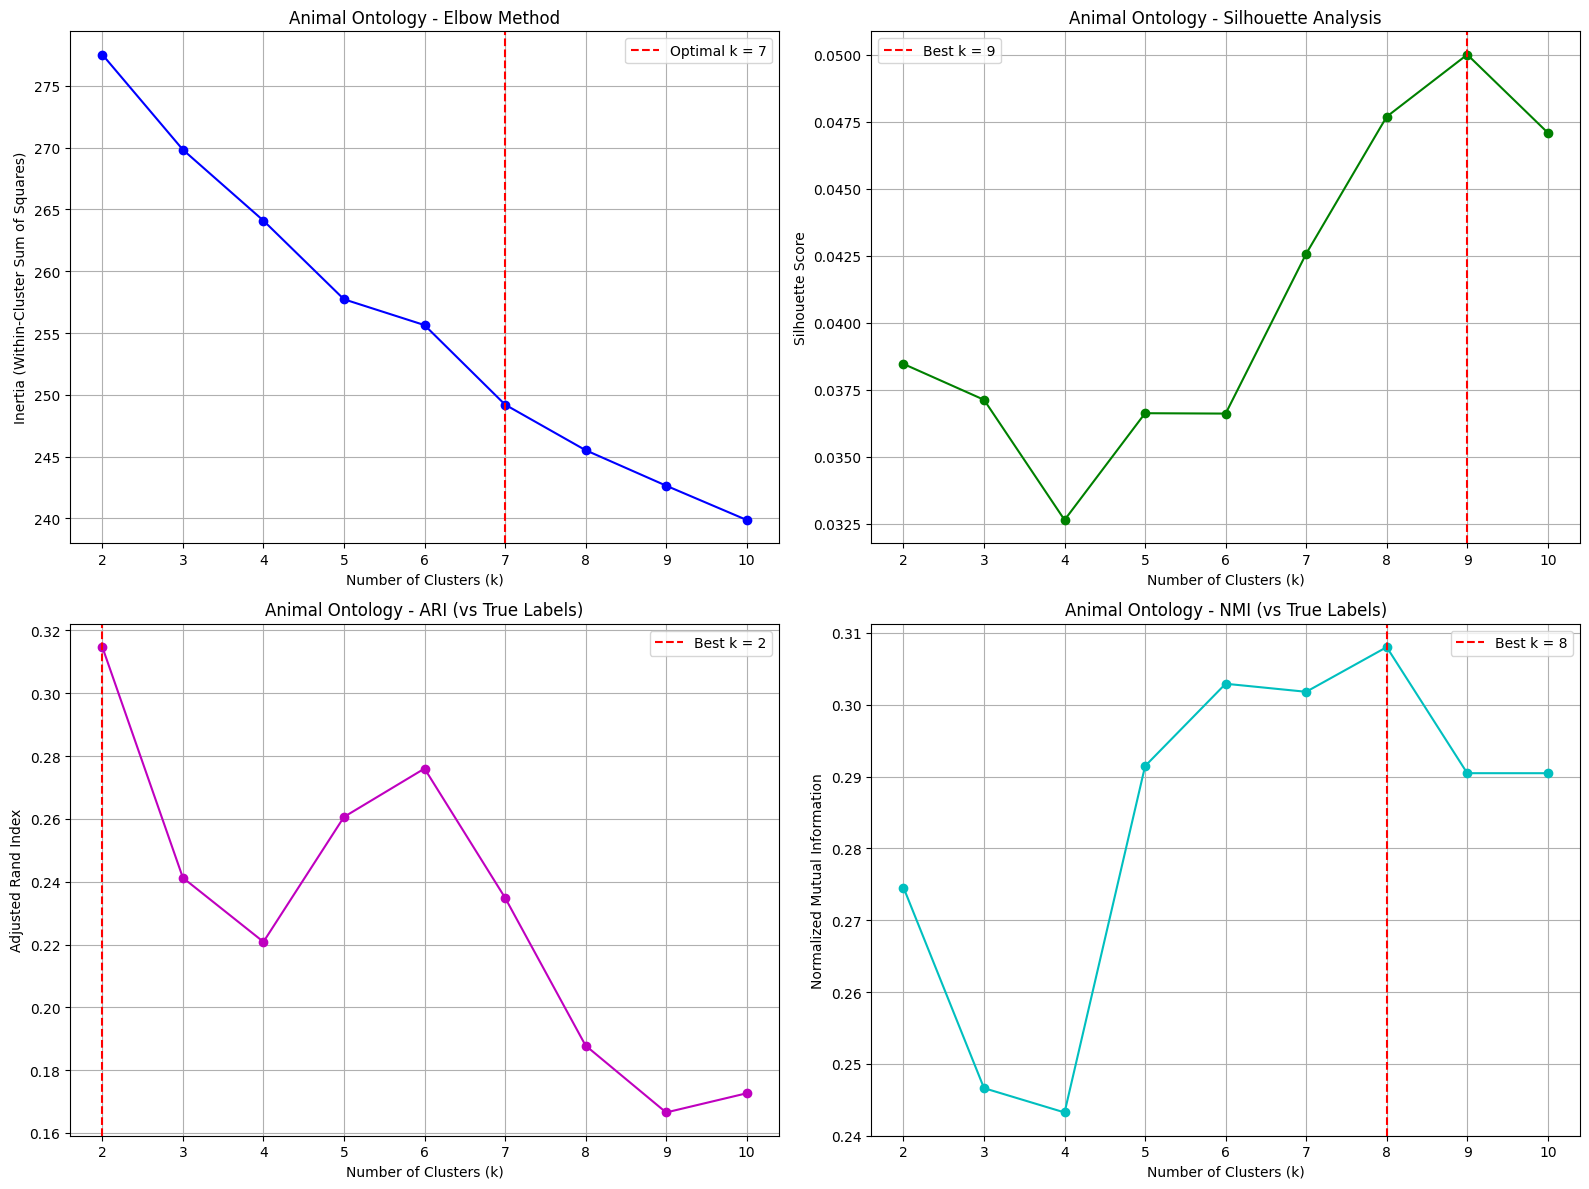

Optimal K:
- elbow_k: 7
- silhouette_k: 9
- ari_k: 2
- nmi_k: 8

 final k: 9
\cluster distribution per category:

Cluster 0 (size: 69)
category
invertebrate       54
vertebrate         14
domestic_animal     1
Name: count, dtype: int64

Cluster 1 (size: 25)
category
domestic_animal    25
Name: count, dtype: int64

Cluster 2 (size: 9)
category
vertebrate    9
Name: count, dtype: int64

Cluster 3 (size: 57)
category
domestic_animal    45
vertebrate          7
invertebrate        5
Name: count, dtype: int64

Cluster 4 (size: 28)
category
vertebrate         23
invertebrate        4
domestic_animal     1
Name: count, dtype: int64

Cluster 5 (size: 53)
category
domestic_animal    44
vertebrate          8
invertebrate        1
Name: count, dtype: int64

Cluster 6 (size: 55)
category
invertebrate       22
domestic_animal    22
vertebrate         11
Name: count, dtype: int64

Cluster 7 (size: 20)
category
domestic_animal    20
Name: count, dtype: int64

Cluster 8 (size: 65)
category
invertebrat

In [35]:
final_k, kmeans_model = run_kmeans_analysis(embedding_array, df)

In [36]:
df['cluster'] = kmeans_model.labels_

for cluster_id in range(final_k):
    cluster_words = df[df['cluster'] == cluster_id]['word'].tolist()
    print(f"Cluster {cluster_id}: {', '.join(cluster_words[:10])}...")

Cluster 0: gnathostome, fish, vertebrate, salamander, anapsid reptile, aquatic vertebrate, tetrapod, fossorial mammal, synapsid reptile, jawless vertebrate...
Cluster 1: carriage dog, pet, toy dog, Welsh corgi, coach dog, pooch, doggie, pug-dog, poodle dog, mutt...
Cluster 2: placental mammal, foetus, abortus, placental, amniote, passerine, Amniota, fetus, baby...
Cluster 3: twitterer, tusker, cock, nester, monster, hen, raptor, woodborer, basket star, instar...
Cluster 4: bird of passage, bird of prey, dickybird, dicky-bird, ratite bird, piciform bird, dickeybird, passeriform bird, flying bird, nonpasserine bird...
Cluster 5: frog, toad frog, eutherian mammal, female mammal, toad, amphibian, mammal, mammalian, moss animal, tortoiseshell-cat...
Cluster 6: trogon, teras, Sinornis, batrachian, gallinacean, Hynerpeton bassetti, Ichyostega, reptilian, salientian, anuran...
Cluster 7: mare, workhorse, wild horse, cow, harness horse, female horse, stalking-horse, riding horse, saddle horse, 

### 4. Visualization

In [38]:
def visualize_clusters(embedding_array, df, k=9, kmeans_model=None):
    if kmeans_model is not None:
        df = df.copy()
        df['cluster'] = kmeans_model.labels_
    else:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        clusters = kmeans.fit_predict(embedding_array)
        df = df.copy()
        df['cluster'] = clusters

    colors = plt.cm.tab10(np.linspace(0, 1, k))
    category_markers = {'vertebrate': 'o', 'invertebrate': 's', 'domestic_animal': '^'}

    # 1. PCA: 2D
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(embedding_array)

    plt.figure(figsize=(12, 10))
    plt.subplot(2, 2, 1)

    for i in range(k):
        cluster_indices = df[df['cluster'] == i].index
        plt.scatter(pca_result[cluster_indices, 0],
                    pca_result[cluster_indices, 1],
                    c=[colors[i]],
                    label=f'Cluster {i}',
                    alpha=0.7)

    plt.title('PCA - Animal Word Embeddings (Colored by Cluster)')
    plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

    # visualization per category
    plt.subplot(2, 2, 2)
    for category, marker in category_markers.items():
        cat_indices = df[df['category'] == category].index
        plt.scatter(pca_result[cat_indices, 0],
                   pca_result[cat_indices, 1],
                   marker=marker,
                   label=category,
                   alpha=0.7)

    plt.title('PCA - Animal Word Embeddings (Colored by Category)')
    plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.legend()

    # 2. t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_result = tsne.fit_transform(embedding_array)

    plt.subplot(2, 2, 3)
    for i in range(k):
        cluster_indices = df[df['cluster'] == i].index
        plt.scatter(tsne_result[cluster_indices, 0],
                   tsne_result[cluster_indices, 1],
                   c=[colors[i]],
                   label=f'Cluster {i}',
                   alpha=0.7)

    plt.title('t-SNE - Animal Word Embeddings (Colored by Cluster)')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')

    plt.subplot(2, 2, 4)
    for category, marker in category_markers.items():
        cat_indices = df[df['category'] == category].index
        plt.scatter(tsne_result[cat_indices, 0],
                   tsne_result[cat_indices, 1],
                   marker=marker,
                   label=category,
                   alpha=0.7)

    plt.title('t-SNE - Animal Word Embeddings (Colored by Category)')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend()

    plt.tight_layout()
    plt.savefig('animal_embeddings_2d.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 3. PCA: 3D
    pca3d = PCA(n_components=3)
    pca3d_result = pca3d.fit_transform(embedding_array)

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(121, projection='3d')
    for i in range(k):
        cluster_indices = df[df['cluster'] == i].index
        ax1.scatter(pca3d_result[cluster_indices, 0],
                   pca3d_result[cluster_indices, 1],
                   pca3d_result[cluster_indices, 2],
                   c=[colors[i]],
                   label=f'Cluster {i}',
                   alpha=0.7)

    ax1.set_title('PCA 3D - Animal Word Embeddings (Colored by Cluster)')
    ax1.set_xlabel(f'PCA 1 ({pca3d.explained_variance_ratio_[0]:.2%})')
    ax1.set_ylabel(f'PCA 2 ({pca3d.explained_variance_ratio_[1]:.2%})')
    ax1.set_zlabel(f'PCA 3 ({pca3d.explained_variance_ratio_[2]:.2%})')
    ax1.legend()

    # per category
    ax2 = fig.add_subplot(122, projection='3d')
    for category, marker in category_markers.items():
        cat_indices = df[df['category'] == category].index
        ax2.scatter(pca3d_result[cat_indices, 0],
                   pca3d_result[cat_indices, 1],
                   pca3d_result[cat_indices, 2],
                   marker=marker,
                   label=category,
                   alpha=0.7)

    ax2.set_title('PCA 3D - Animal Word Embeddings (Colored by Category)')
    ax2.set_xlabel(f'PCA 1 ({pca3d.explained_variance_ratio_[0]:.2%})')
    ax2.set_ylabel(f'PCA 2 ({pca3d.explained_variance_ratio_[1]:.2%})')
    ax2.set_zlabel(f'PCA 3 ({pca3d.explained_variance_ratio_[2]:.2%})')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('animal_embeddings_3d.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 4. distribution of representative words and category
    print("\nCluster Analysis:")
    for i in range(k):
        cluster_df = df[df['cluster'] == i]
        print(f"\nCluster {i} (Size: {len(cluster_df)})")
        print("Category Distribution:")
        print(cluster_df['category'].value_counts())
        print("10 Representative Words:")
        print(", ".join(cluster_df['word'].sample(min(10, len(cluster_df))).tolist()))

    return df

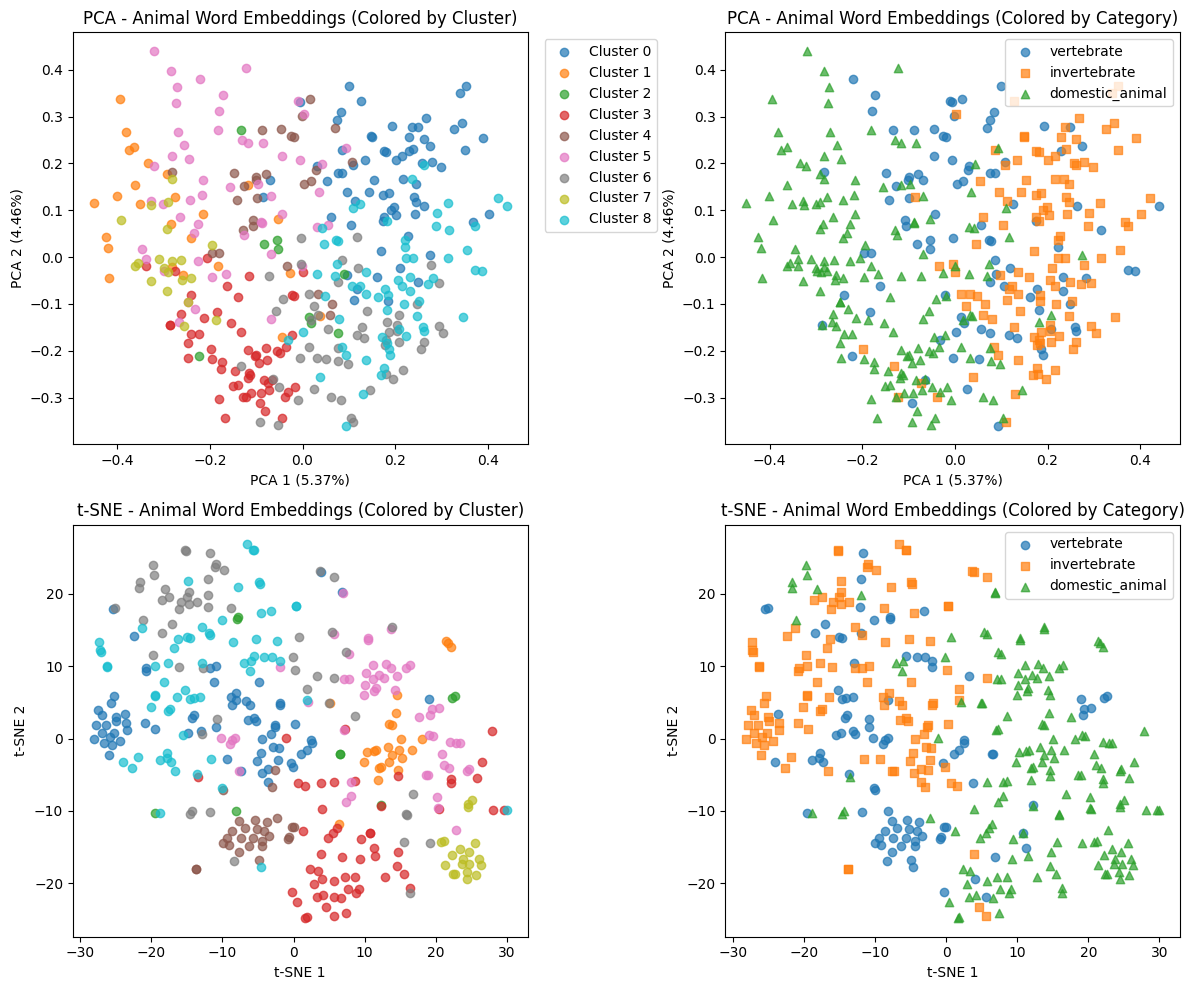

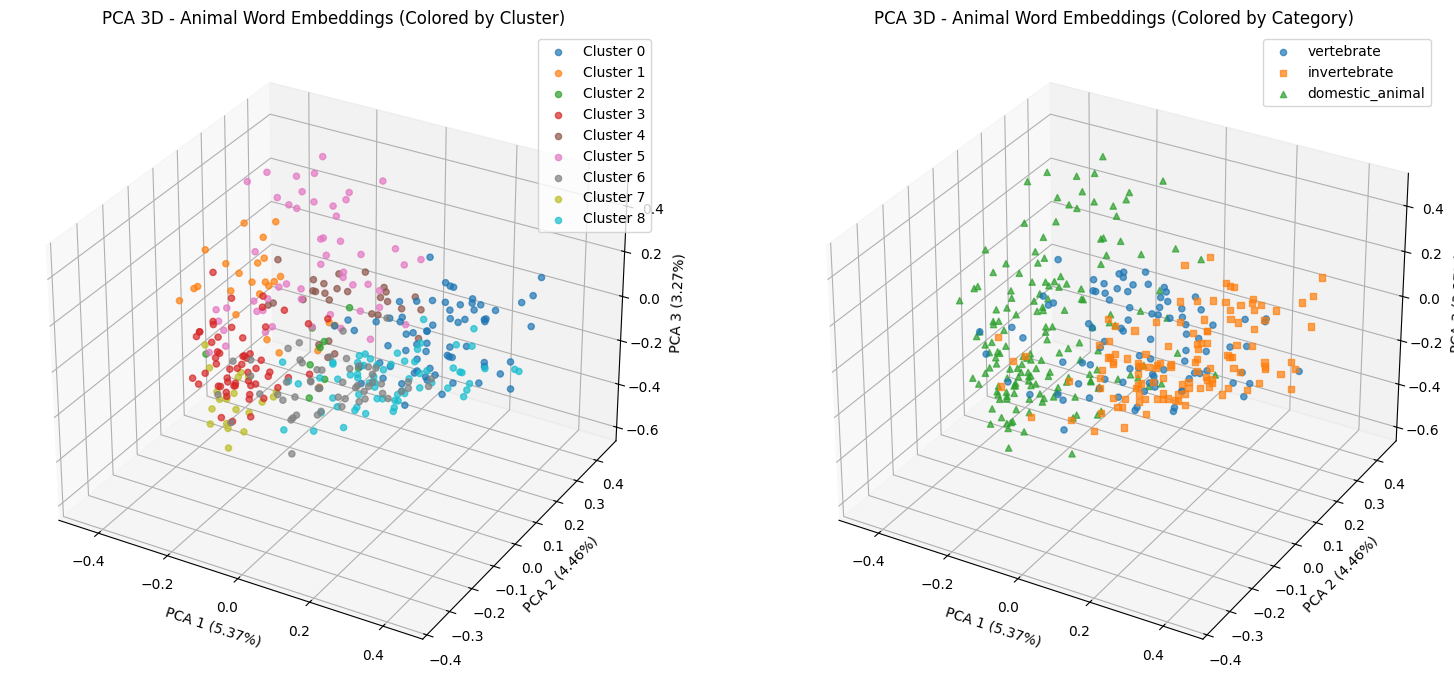


Cluster Analysis:

Cluster 0 (Size: 69)
Category Distribution:
category
invertebrate       54
vertebrate         14
domestic_animal     1
Name: count, dtype: int64
10 Representative Words:
pelecypod, jawless vertebrate, basket fish, brachiopod, parasitic worm, arrowworm, sponge, beard worm, gastropod, insect

Cluster 1 (Size: 25)
Category Distribution:
category
domestic_animal    25
Name: count, dtype: int64
10 Representative Words:
hunting dog, dog, poodle, lapdog, Newfoundland, Maltese, puppy, pug-dog, Newfoundland dog, doggy

Cluster 2 (Size: 9)
Category Distribution:
category
vertebrate    9
Name: count, dtype: int64
10 Representative Words:
placental mammal, placental, foetus, passerine, Amniota, abortus, amniote, baby, fetus

Cluster 3 (Size: 57)
Category Distribution:
category
domestic_animal    45
vertebrate          7
invertebrate        5
Name: count, dtype: int64
10 Representative Words:
nag, squealer, billy goat, monster, hen, plug, borer, chicken, head, puss

Cluster 4 (S

In [39]:
clustered_df = visualize_clusters(embedding_array, df, k=final_k, kmeans_model=kmeans_model)

### 5. Cosine Similarity Analysis

In [41]:
def perform_cosine_similarity_analysis(embedding_array, df):
    # 1. Calculate and analyze category centroids
    print("Cosine Similarity Analysis Between Categories")
    categories = df['category'].unique()
    category_centers = {}

    for category in categories:
        cat_indices = df[df['category'] == category].index
        category_centers[category] = np.mean(embedding_array[cat_indices], axis=0)

    # Calculate cosine similarity between categories
    category_similarity = np.zeros((len(categories), len(categories)))
    for i, cat1 in enumerate(categories):
        for j, cat2 in enumerate(categories):
            similarity = 1 - cosine(category_centers[cat1], category_centers[cat2])
            category_similarity[i, j] = similarity

    # Visualize similarity heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(category_similarity, annot=True, fmt=".3f",
               xticklabels=categories, yticklabels=categories, cmap='Blues')
    plt.title('Cosine Similarity Between Categories')
    plt.tight_layout()
    plt.savefig('category_similarity.png', dpi=300)
    plt.show()

    # 2. Calculate and analyze cluster centroids
    print("\nCosine Similarity Analysis Between Clusters")
    clusters = sorted(df['cluster'].unique())
    cluster_centers = {}

    for cluster in clusters:
        cluster_indices = df[df['cluster'] == cluster].index
        cluster_centers[cluster] = np.mean(embedding_array[cluster_indices], axis=0)

    # Calculate cosine similarity between clusters
    cluster_similarity = np.zeros((len(clusters), len(clusters)))
    for i, c1 in enumerate(clusters):
        for j, c2 in enumerate(clusters):
            similarity = 1 - cosine(cluster_centers[c1], cluster_centers[c2])
            cluster_similarity[i, j] = similarity

    # Visualize similarity heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(cluster_similarity, annot=True, fmt=".3f",
               xticklabels=[f"C{c}" for c in clusters],
               yticklabels=[f"C{c}" for c in clusters],
               cmap='Greens')
    plt.title('Cosine Similarity Between Clusters')
    plt.tight_layout()
    plt.savefig('cluster_similarity.png', dpi=300)
    plt.show()

    # 3. Analyze similarity between representative words
    print("\nCosine Similarity Analysis Between Representative Words")
    # Select representative words from each category and cluster
    representative_words = {}
    word_embeddings = {}

    # Select 5 representative words from each category
    for category in categories:
        cat_words = df[df['category'] == category]['word'].tolist()
        # Select 5 representative words (closest to the centroid)
        cat_indices = df[df['category'] == category].index
        cat_embeddings = embedding_array[cat_indices]
        cat_center = np.mean(cat_embeddings, axis=0)

        # Sort by distance to center
        distances = [cosine(cat_center, embedding_array[idx]) for idx in cat_indices]
        sorted_indices = np.argsort(distances)
        rep_indices = sorted_indices[:5]  # Select 5 closest to the center

        representative_words[category] = [df.iloc[cat_indices[i]]['word'] for i in rep_indices]

        for i in rep_indices:
            word = df.iloc[cat_indices[i]]['word']
            word_embeddings[word] = embedding_array[cat_indices[i]]

    # List of all representative words
    all_rep_words = []
    for words in representative_words.values():
        all_rep_words.extend(words)

    # Calculate cosine similarity between representative words
    word_similarity = np.zeros((len(all_rep_words), len(all_rep_words)))
    for i, word1 in enumerate(all_rep_words):
        for j, word2 in enumerate(all_rep_words):
            similarity = 1 - cosine(word_embeddings[word1], word_embeddings[word2])
            word_similarity[i, j] = similarity

    # Visualize similarity heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(word_similarity, annot=True, fmt=".2f",
               xticklabels=all_rep_words, yticklabels=all_rep_words,
               cmap='Reds')
    plt.title('Cosine Similarity Between Representative Words')
    plt.tight_layout()
    plt.savefig('word_similarity.png', dpi=300)
    plt.show()

    # 4. Hierarchy structure analysis
    print("\nHierarchy Structure Analysis (Parent vs Child Categories)")

    # Define example hierarchy structure
    hierarchy = {
        'animal': list(categories),  # Top level includes all categories
        'vertebrate': ['mammal', 'bird', 'reptile', 'fish'],  # Example subcategories
        'invertebrate': ['insect', 'arachnid', 'crustacean'],  # Example subcategories
        'domestic_animal': ['dog', 'cat', 'horse']  # Example subcategories
    }

    # Collect embeddings for all words in the hierarchy
    hierarchy_embeddings = {}

    # Step 1: Use category embeddings (already calculated)
    for category in categories:
        hierarchy_embeddings[category] = category_centers[category]

    # Step 2: Calculate embedding for top category 'animal'
    hierarchy_embeddings['animal'] = np.mean([category_centers[cat] for cat in categories], axis=0)

    # Step 3: Find and calculate embeddings for subcategory words
    for parent, children in hierarchy.items():
        if parent != 'animal':  # 'animal' is already processed
            for child in children:
                # Check if the word exists in the dataset
                child_indices = df[df['word'] == child].index

                if len(child_indices) > 0:
                    # If the word exists, use its embedding
                    hierarchy_embeddings[child] = embedding_array[child_indices[0]]
                else:
                    # If the word doesn't exist, find similar words
                    similar_words = [w for w in df['word'] if child in w]
                    if similar_words:
                        similar_indices = df[df['word'].isin(similar_words)].index
                        hierarchy_embeddings[child] = np.mean(embedding_array[similar_indices], axis=0)

    # Analyze cosine similarity in parent-child relationships within the hierarchy
    print("\nCosine Similarity in Parent-Child Relationships:")
    for parent, children in hierarchy.items():
        if parent in hierarchy_embeddings:
            print(f"\nParent Category: {parent}")
            for child in children:
                if child in hierarchy_embeddings:
                    similarity = 1 - cosine(hierarchy_embeddings[parent], hierarchy_embeddings[child])
                    print(f"  - {parent} → {child}: {similarity:.4f}")

    return {
        'category_similarity': category_similarity,
        'cluster_similarity': cluster_similarity,
        'word_similarity': word_similarity,
        'representative_words': representative_words,
        'hierarchy_embeddings': hierarchy_embeddings
    }

Cosine Similarity Analysis Between Categories


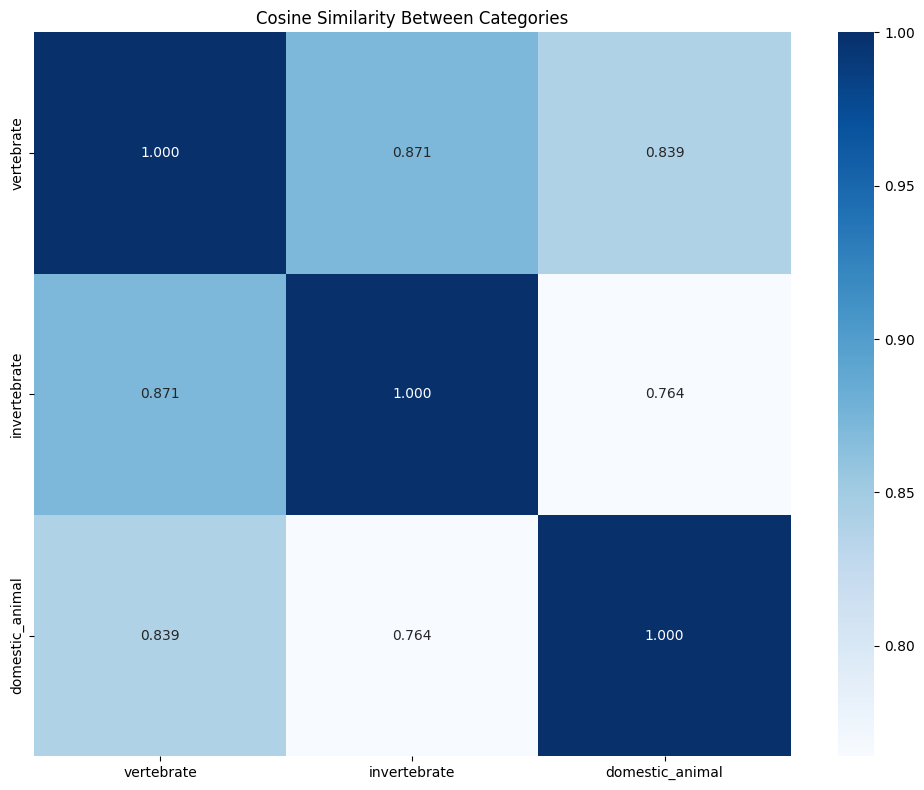


Cosine Similarity Analysis Between Clusters


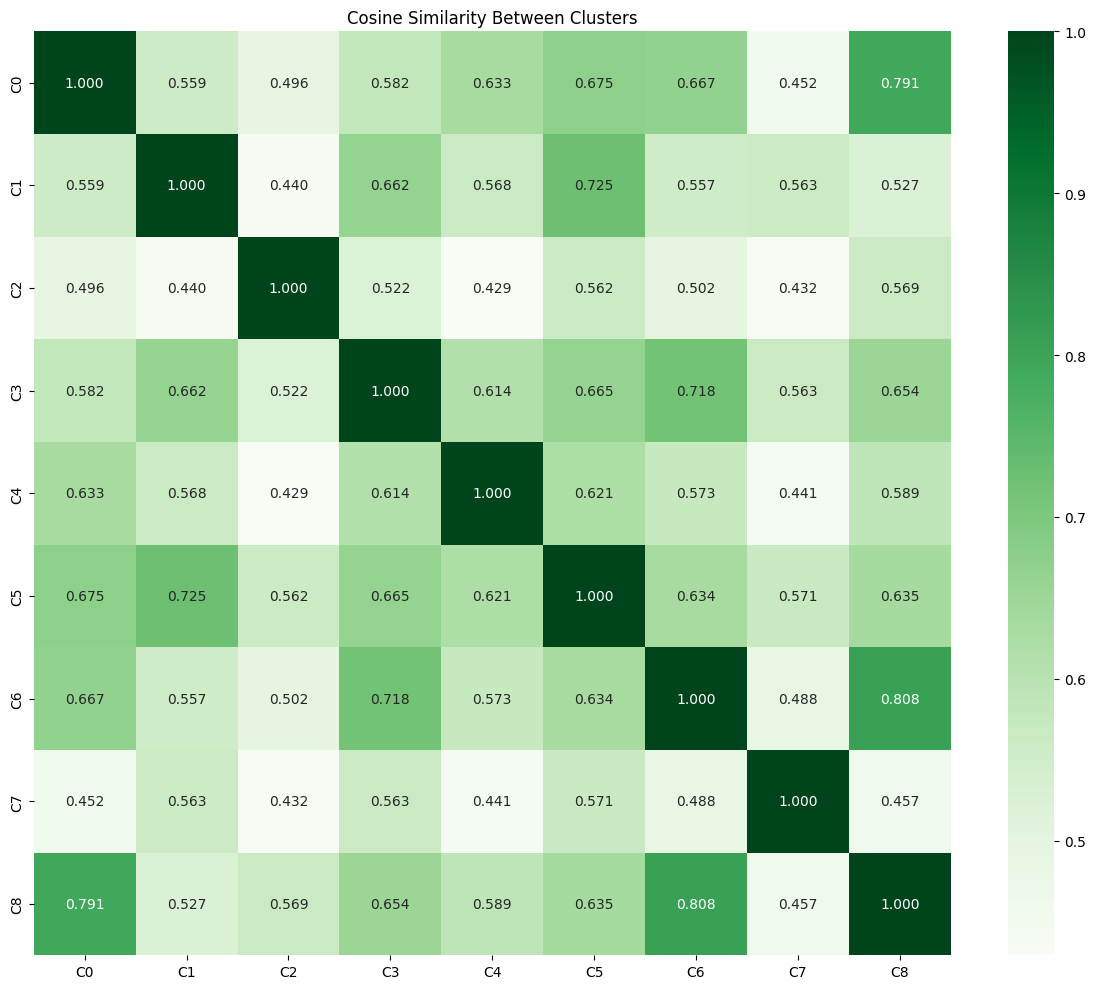


Cosine Similarity Analysis Between Representative Words


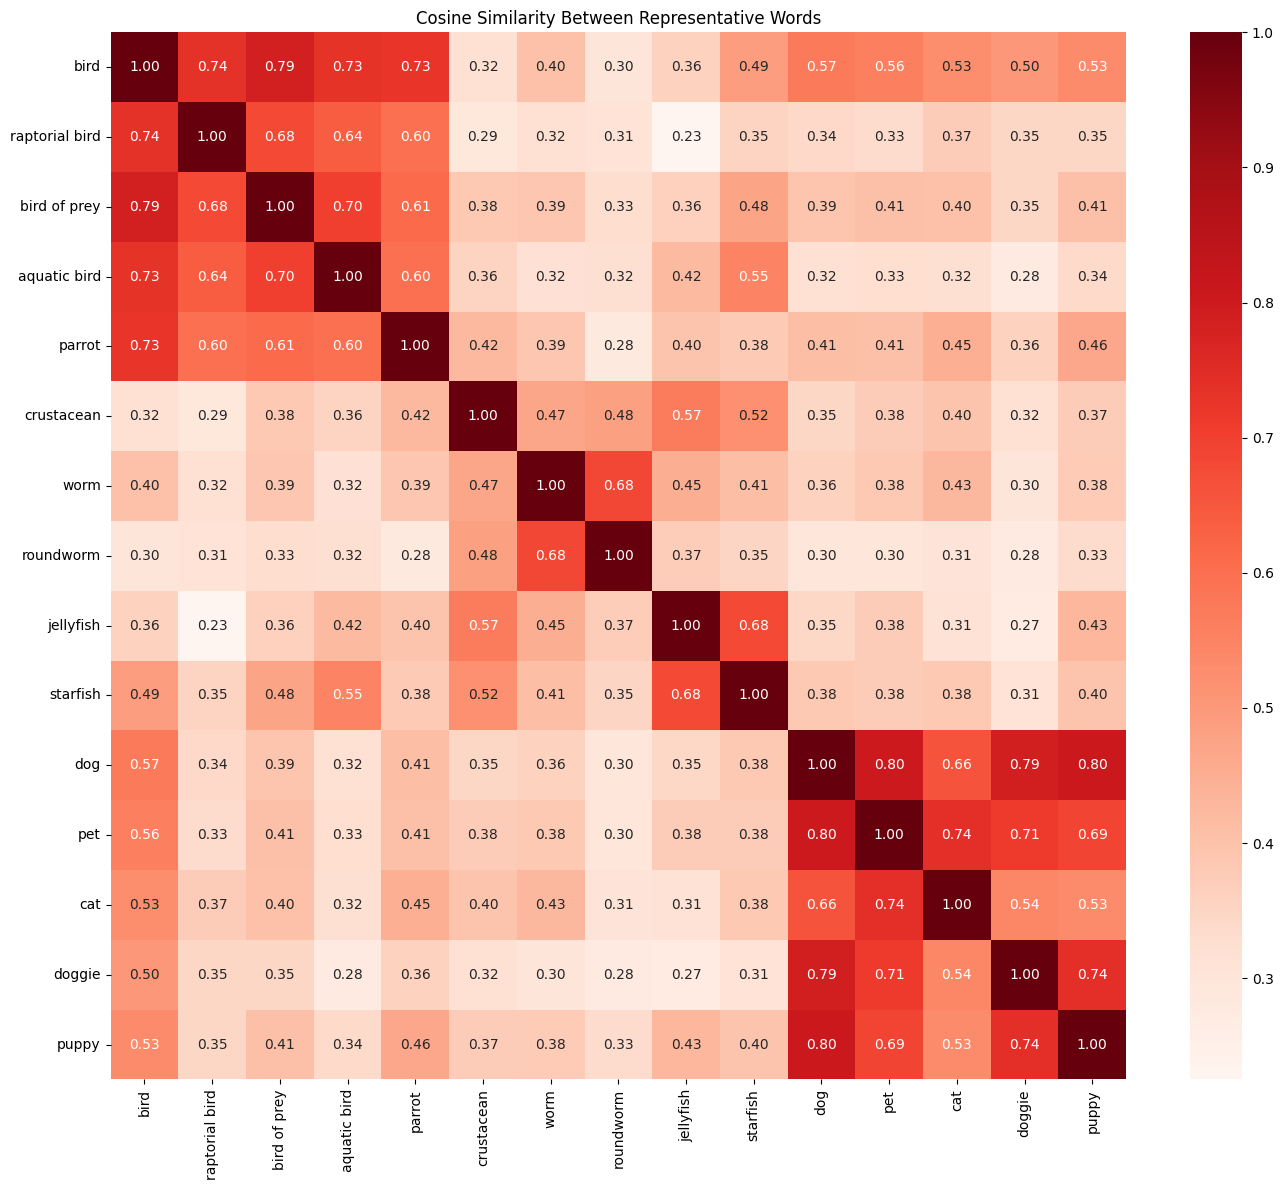


Hierarchy Structure Analysis (Parent vs Child Categories)

Cosine Similarity in Parent-Child Relationships:

Parent Category: animal
  - animal → vertebrate: 0.9623
  - animal → invertebrate: 0.9352
  - animal → domestic_animal: 0.9218

Parent Category: vertebrate
  - vertebrate → mammal: 0.6382
  - vertebrate → bird: 0.7507
  - vertebrate → reptile: 0.6549
  - vertebrate → fish: 0.5892

Parent Category: invertebrate
  - invertebrate → insect: 0.6331
  - invertebrate → arachnid: 0.5599
  - invertebrate → crustacean: 0.7248

Parent Category: domestic_animal
  - domestic_animal → dog: 0.7405
  - domestic_animal → cat: 0.7252
  - domestic_animal → horse: 0.6996


In [42]:
similarity_results = perform_cosine_similarity_analysis(embedding_array, df)

### 6. Hierarchy Analysis

In [44]:
def build_ontology_hierarchy():
    """
    Builds a hierarchical ontology structure for animal categories.

    Returns:
        dict: A nested dictionary representing the ontology hierarchy
    """
    # Define the ontology hierarchy
    ontology_hierarchy = {
        'animal': {
            'vertebrate': {
                'mammal': {
                    'carnivore': {'dog', 'cat', 'tiger', 'bear'},
                    'primate': {'human', 'chimpanzee', 'gorilla'},
                    'rodent': {'mouse', 'rat', 'squirrel'},
                    'aquatic_mammal': {'dolphin', 'whale'}
                },
                'bird': {
                    'songbird': {'robin', 'sparrow'},
                    'raptor': {'eagle', 'hawk'},
                    'waterfowl': {'duck', 'goose'}
                },
                'reptile': {
                    'snake': {'python', 'cobra'},
                    'lizard': {'gecko', 'iguana'},
                    'turtle': {'tortoise', 'sea_turtle'}
                },
                'fish': {
                    'teleost': {'salmon', 'tuna'},
                    'elasmobranch': {'shark', 'ray'}
                }
            },
            'invertebrate': {
                'insect': {
                    'beetle': {'ladybug', 'firefly'},
                    'butterfly': {'monarch', 'swallowtail'},
                    'ant': {'fire_ant', 'carpenter_ant'}
                },
                'arachnid': {
                    'spider': {'tarantula', 'black_widow'},
                    'scorpion': {'emperor_scorpion'}
                },
                'crustacean': {
                    'crab': {'hermit_crab', 'blue_crab'},
                    'shrimp': {'mantis_shrimp', 'krill'}
                },
                'mollusk': {
                    'cephalopod': {'squid', 'octopus'},
                    'gastropod': {'snail', 'slug'}
                }
            },
            'domestic_animal': {
                'pet': {
                    'dog': {'german_shepherd', 'poodle'},
                    'cat': {'persian_cat', 'siamese_cat'},
                    'small_pet': {'hamster', 'guinea_pig'}
                },
                'livestock': {
                    'cattle': {'cow', 'bull'},
                    'horse': {'thoroughbred', 'clydesdale'},
                    'poultry': {'chicken', 'turkey'}
                }
            }
        }
    }

    return ontology_hierarchy

In [45]:
def get_category_embeddings(embedding_array, df, categories):
    """
    Calculate embeddings for each category by averaging word embeddings.

    Args:
        embedding_array (np.ndarray): Array of word embeddings
        df (pd.DataFrame): DataFrame containing words and categories
        categories (list): List of category names

    Returns:
        dict: Dictionary mapping categories to their embeddings
    """
    category_embeddings = {}

    for category in categories:
        # Get indices of words in this category
        cat_indices = df[df['category'] == category].index
        if len(cat_indices) > 0:
            # Calculate the average embedding for this category
            category_embeddings[category] = np.mean(embedding_array[cat_indices], axis=0)

    return category_embeddings

In [55]:
def find_word_embeddings(embedding_array, df, ontology_hierarchy, category_embeddings):
    """
    Find embeddings for words in the ontology hierarchy.

    Args:
        embedding_array (np.ndarray): Array of word embeddings
        df (pd.DataFrame): DataFrame containing words
        ontology_hierarchy (dict): The ontology hierarchy
        category_embeddings (dict): Dictionary of category embeddings

    Returns:
        dict: Dictionary mapping each term in the hierarchy to its embedding
    """
    hierarchy_embeddings = category_embeddings.copy()

    # Recursively traverse the hierarchy to find embeddings for all terms
    def traverse_hierarchy(hierarchy, prefix=""):
        for key, value in hierarchy.items():
            current_term = key

            # Skip if we already have the embedding
            if current_term in hierarchy_embeddings:
                continue

            # Try to find the word in the dataset
            word_indices = df[df['word'] == current_term].index

            if len(word_indices) > 0:
                # Use the embedding of the first matching word
                hierarchy_embeddings[current_term] = embedding_array[word_indices[0]]
            else:
                # Try to find similar words
                similar_words = df[df['word'].str.contains(current_term, case=False)]

                if len(similar_words) > 0:
                    # Average embeddings of similar words
                    similar_indices = similar_words.index
                    hierarchy_embeddings[current_term] = np.mean(embedding_array[similar_indices], axis=0)
                elif prefix in hierarchy_embeddings:
                    # If no match found but we have a parent, use parent's embedding as fallback
                    hierarchy_embeddings[current_term] = hierarchy_embeddings[prefix]
                else:
                    # If all else fails, use a random embedding from the dataset as placeholder
                    # This ensures we don't have empty arrays
                    print(f"Warning: No embedding found for '{current_term}', using placeholder.")
                    if len(df) > 0:
                        hierarchy_embeddings[current_term] = embedding_array[0]  # Use first embedding as placeholder

            # Recursively process child items if value is a dictionary
            if isinstance(value, dict):
                traverse_hierarchy(value, current_term)

    # Start traversal from the top level
    for key, value in ontology_hierarchy.items():
        if key not in hierarchy_embeddings and len(df) > 0:
            # Ensure top-level terms have embeddings
            hierarchy_embeddings[key] = np.mean(embedding_array, axis=0)
        traverse_hierarchy(value, key)

    return hierarchy_embeddings

In [56]:
def calculate_hierarchical_similarities(hierarchy_embeddings, ontology_hierarchy):
    """
    Calculate cosine similarities between parent and child categories.

    Args:
        hierarchy_embeddings (dict): Dictionary of embeddings for terms in the hierarchy
        ontology_hierarchy (dict): The ontology hierarchy

    Returns:
        list: List of dictionaries containing parent-child relationships and similarities
    """
    similarity_results = []

    def traverse_hierarchy(hierarchy, parent=""):
        for key, value in hierarchy.items():
            current_term = key

            # Skip if we don't have embeddings for either parent or current term
            if parent not in hierarchy_embeddings or current_term not in hierarchy_embeddings:
                continue

            # Calculate cosine similarity
            try:
                similarity = 1 - cosine(hierarchy_embeddings[parent], hierarchy_embeddings[current_term])

                similarity_results.append({
                    'parent': parent,
                    'child': current_term,
                    'similarity': similarity
                })
            except Exception as e:
                print(f"Warning: Could not calculate similarity between '{parent}' and '{current_term}': {e}")

            # Recursively process child items if value is a dictionary
            if isinstance(value, dict):
                traverse_hierarchy(value, current_term)

    # Start traversal from the top level
    for key, value in ontology_hierarchy.items():
        traverse_hierarchy(value, key)

    return similarity_results

In [48]:
def project_embeddings_to_2d(hierarchy_embeddings):
    """
    Project embeddings to 2D space using PCA.

    Args:
        hierarchy_embeddings (dict): Dictionary of embeddings

    Returns:
        dict: Dictionary mapping terms to their 2D coordinates
    """
    # Extract embeddings and corresponding terms
    terms = list(hierarchy_embeddings.keys())
    embeddings = np.array([hierarchy_embeddings[term] for term in terms])

    # Apply PCA to reduce to 2 dimensions
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(embeddings)

    # Create a mapping from term to 2D coordinates
    term_to_coords = {terms[i]: reduced_embeddings[i] for i in range(len(terms))}

    return term_to_coords, pca.explained_variance_ratio_

In [49]:
def visualize_hierarchy_with_arrows(term_to_coords, similarity_results, ontology_hierarchy, variance_ratio):
    """
    Visualize the ontology hierarchy with arrows showing parent-child relationships.

    Args:
        term_to_coords (dict): Dictionary mapping terms to 2D coordinates
        similarity_results (list): List of parent-child relationships and similarities
        ontology_hierarchy (dict): The ontology hierarchy
        variance_ratio (np.ndarray): PCA explained variance ratios
    """
    plt.figure(figsize=(14, 12))

    # Define colors for different levels of the hierarchy
    level_colors = {
        0: '#1f77b4',  # Top level (animal)
        1: '#ff7f0e',  # Second level (vertebrate, invertebrate, domestic_animal)
        2: '#2ca02c',  # Third level (mammal, bird, etc.)
        3: '#d62728',  # Fourth level
        4: '#9467bd',  # Fifth level
    }

    # Define node sizes for different levels
    level_sizes = {
        0: 300,
        1: 200,
        2: 150,
        3: 100,
        4: 50
    }

    # Create a mapping of terms to their hierarchy level
    term_to_level = {}

    def assign_levels(hierarchy, level=0, prefix=""):
        for key, value in hierarchy.items():
            term_to_level[key] = level
            if isinstance(value, dict):
                assign_levels(value, level+1, key)

    # Start assigning levels from the top
    for key, value in ontology_hierarchy.items():
        term_to_level[key] = 0
        assign_levels(value, 1, key)

    # Plot nodes (terms)
    for term, coord in term_to_coords.items():
        level = term_to_level.get(term, 0)
        color = level_colors.get(level, 'gray')
        size = level_sizes.get(level, 50)

        plt.scatter(coord[0], coord[1], c=color, s=size, edgecolor='black', zorder=2)
        plt.text(coord[0] + 0.01, coord[1] + 0.01, term, fontsize=9, zorder=3)

    # Plot arrows (parent-child relationships)
    for rel in similarity_results:
        parent = rel['parent']
        child = rel['child']
        similarity = rel['similarity']

        if parent in term_to_coords and child in term_to_coords:
            parent_coord = term_to_coords[parent]
            child_coord = term_to_coords[child]

            # Calculate arrow properties based on similarity
            alpha = min(1.0, max(0.2, similarity))  # Transparency based on similarity
            width = min(2.0, max(0.5, similarity * 2))  # Width based on similarity

            plt.arrow(parent_coord[0], parent_coord[1],
                      child_coord[0] - parent_coord[0],
                      child_coord[1] - parent_coord[1],
                      head_width=0.02, length_includes_head=True,
                      alpha=alpha, width=width * 0.001,
                      fc='gray', ec='gray', zorder=1)

    plt.title("Animal Ontology Hierarchy Visualization (PCA 2D)")
    plt.xlabel(f"PC1 ({variance_ratio[0]:.2%} variance explained)")
    plt.ylabel(f"PC2 ({variance_ratio[1]:.2%} variance explained)")
    plt.grid(True, linestyle='--', alpha=0.7)

    # Create a custom legend for hierarchy levels
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=level_colors[i],
               label=f'Level {i}', markersize=10)
        for i in range(5)
    ]
    plt.legend(handles=legend_elements, title="Hierarchy Level",
               loc='upper right', bbox_to_anchor=(1.15, 1))

    plt.tight_layout()
    plt.savefig('ontology_hierarchy_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

In [50]:
def visualize_similarity_matrix(similarity_results, hierarchy_embeddings):
    """
    Visualize the similarity matrix between hierarchy terms.

    Args:
        similarity_results (list): List of parent-child relationships and similarities
        hierarchy_embeddings (dict): Dictionary of embeddings for hierarchy terms
    """
    # Get unique terms from similarity results
    terms = set()
    for result in similarity_results:
        terms.add(result['parent'])
        terms.add(result['child'])
    terms = sorted(list(terms))

    # Create similarity matrix
    n_terms = len(terms)
    similarity_matrix = np.zeros((n_terms, n_terms))

    for i, term1 in enumerate(terms):
        for j, term2 in enumerate(terms):
            if term1 in hierarchy_embeddings and term2 in hierarchy_embeddings:
                similarity = 1 - cosine(hierarchy_embeddings[term1], hierarchy_embeddings[term2])
                similarity_matrix[i, j] = similarity

    # Visualize the similarity matrix
    plt.figure(figsize=(14, 12))
    sns.heatmap(similarity_matrix, annot=False, fmt=".2f",
                xticklabels=terms, yticklabels=terms, cmap='viridis')
    plt.title('Cosine Similarity Between Ontology Terms')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('ontology_similarity_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

In [51]:
def analyze_hierarchy_alignment(similarity_results):
    """
    Analyze how well the hierarchy alignment is reflected in embedding space.

    Args:
        similarity_results (list): List of parent-child relationships and similarities

    Returns:
        dict: Dictionary with analysis results
    """
    similarities = [result['similarity'] for result in similarity_results]

    # Calculate statistics
    avg_similarity = np.mean(similarities)
    median_similarity = np.median(similarities)
    min_similarity = np.min(similarities)
    max_similarity = np.max(similarities)

    # Group by parent
    parent_to_children = {}
    for result in similarity_results:
        parent = result['parent']
        if parent not in parent_to_children:
            parent_to_children[parent] = []
        parent_to_children[parent].append({
            'child': result['child'],
            'similarity': result['similarity']
        })

    # Sort parent-child pairs by similarity (highest to lowest)
    top_similarities = sorted(similarity_results, key=lambda x: x['similarity'], reverse=True)
    bottom_similarities = sorted(similarity_results, key=lambda x: x['similarity'])

    analysis_results = {
        'avg_similarity': avg_similarity,
        'median_similarity': median_similarity,
        'min_similarity': min_similarity,
        'max_similarity': max_similarity,
        'top_similarities': top_similarities[:10],
        'bottom_similarities': bottom_similarities[:10],
        'parent_to_children': parent_to_children
    }

    # Print analysis results
    print("Hierarchy Alignment Analysis")
    print(f"Average Parent-Child Similarity: {avg_similarity:.4f}")
    print(f"Median Parent-Child Similarity: {median_similarity:.4f}")
    print(f"Minimum Parent-Child Similarity: {min_similarity:.4f}")
    print(f"Maximum Parent-Child Similarity: {max_similarity:.4f}")

    print("\nTop 10 Strongest Parent-Child Relationships:")
    for i, rel in enumerate(top_similarities[:10], 1):
        print(f"{i}. {rel['parent']} → {rel['child']}: {rel['similarity']:.4f}")

    print("\nBottom 10 Weakest Parent-Child Relationships:")
    for i, rel in enumerate(bottom_similarities[:10], 1):
        print(f"{i}. {rel['parent']} → {rel['child']}: {rel['similarity']:.4f}")

    return analysis_results

In [52]:
def create_networkx_graph(similarity_results, term_to_coords):
    """
    Create a NetworkX graph visualization of the ontology.

    Args:
        similarity_results (list): List of parent-child relationships and similarities
        term_to_coords (dict): Dictionary mapping terms to 2D coordinates
    """
    G = nx.DiGraph()

    # Add nodes with positions
    for term, coord in term_to_coords.items():
        G.add_node(term, pos=coord)

    # Add edges with weights based on similarity
    for rel in similarity_results:
        parent = rel['parent']
        child = rel['child']
        similarity = rel['similarity']

        if parent in term_to_coords and child in term_to_coords:
            G.add_edge(parent, child, weight=similarity)

    # Get positions for nodes
    pos = nx.get_node_attributes(G, 'pos')

    # Create edge weights for line thickness
    edge_weights = [G[u][v]['weight'] * 3 for u, v in G.edges()]

    # Draw the graph
    plt.figure(figsize=(16, 14))

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=100, alpha=0.8)

    # Draw edges with varying thickness based on similarity
    nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.6,
                          edge_color='gray', arrows=True, arrowsize=15)

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=8)

    plt.title("Animal Ontology Network Graph")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('ontology_network_graph.png', dpi=300, bbox_inches='tight')
    plt.show()

In [57]:
def perform_hierarchy_analysis(embedding_array, df):
    """
    Main function to perform the complete hierarchy analysis.

    Args:
        embedding_array (np.ndarray): Array of word embeddings
        df (pd.DataFrame): DataFrame containing words and categories

    Returns:
        dict: Dictionary with analysis results
    """
    print("Starting Ontology Hierarchy Analysis")

    # Check if we have data to work with
    if len(df) == 0 or embedding_array.size == 0:
        print("Error: Empty dataframe or embedding array provided.")
        return None

    # Get list of categories
    categories = df['category'].unique()
    if len(categories) == 0:
        print("Error: No categories found in the dataframe.")
        return None

    # 1. Build ontology hierarchy
    ontology_hierarchy = build_ontology_hierarchy()

    # 2. Get category embeddings
    category_embeddings = get_category_embeddings(embedding_array, df, categories)

    # Check if we have enough category embeddings
    if len(category_embeddings) == 0:
        print("Error: No category embeddings could be calculated.")
        return None

    # 3. Find embeddings for all terms in the hierarchy
    hierarchy_embeddings = find_word_embeddings(embedding_array, df, ontology_hierarchy, category_embeddings)

    # 4. Calculate hierarchical similarities
    similarity_results = calculate_hierarchical_similarities(hierarchy_embeddings, ontology_hierarchy)

    # Check if we have similarity results
    if len(similarity_results) == 0:
        print("Error: No hierarchical similarities could be calculated.")
        return None

    # 5. Project embeddings to 2D for visualization
    term_to_coords, variance_ratio = project_embeddings_to_2d(hierarchy_embeddings)

    # 6. Visualize hierarchy with arrows
    visualize_hierarchy_with_arrows(term_to_coords, similarity_results, ontology_hierarchy, variance_ratio)

    # 7. Visualize similarity matrix
    visualize_similarity_matrix(similarity_results, hierarchy_embeddings)

    # 8. Create network graph visualization
    create_networkx_graph(similarity_results, term_to_coords)

    # 9. Analyze hierarchy alignment
    analysis_results = analyze_hierarchy_alignment(similarity_results)

    return {
        'ontology_hierarchy': ontology_hierarchy,
        'hierarchy_embeddings': hierarchy_embeddings,
        'similarity_results': similarity_results,
        'term_to_coords': term_to_coords,
        'analysis_results': analysis_results
    }

In [58]:
print(f"Embedding array shape: {embedding_array.shape}")
print(f"Number of categories: {len(df['category'].unique())}")
print(f"First few categories: {df['category'].unique()[:5]}")

Embedding array shape: (381, 384)
Number of categories: 3
First few categories: ['vertebrate' 'invertebrate' 'domestic_animal']


Starting Ontology Hierarchy Analysis


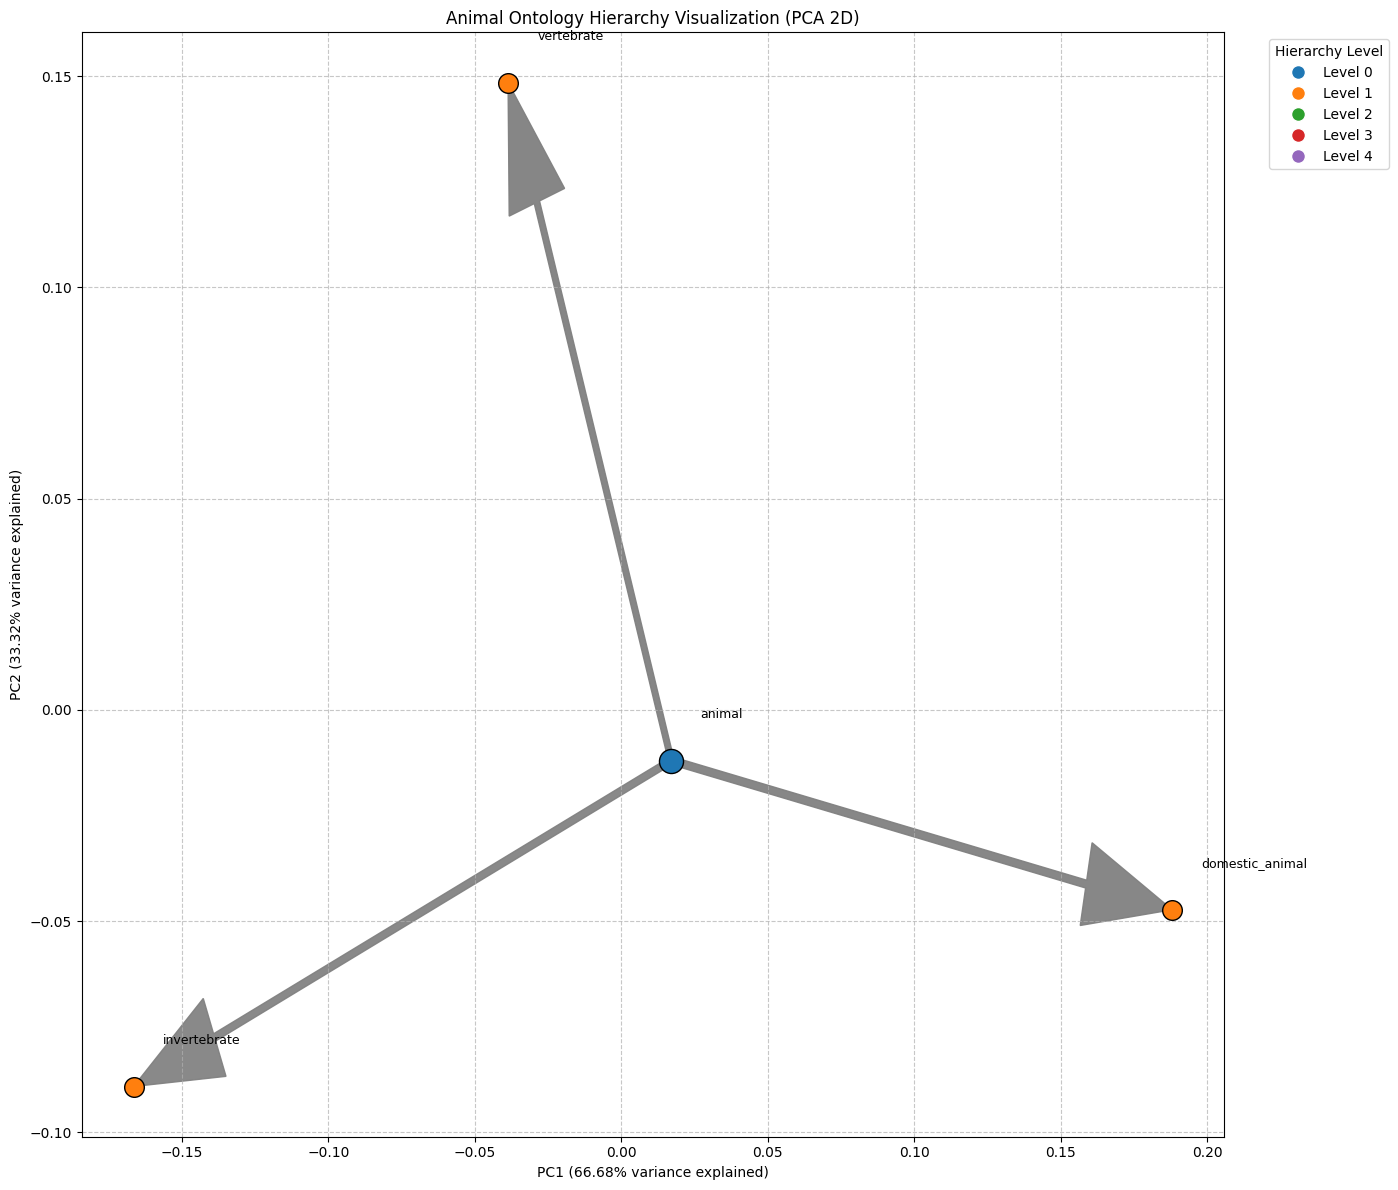

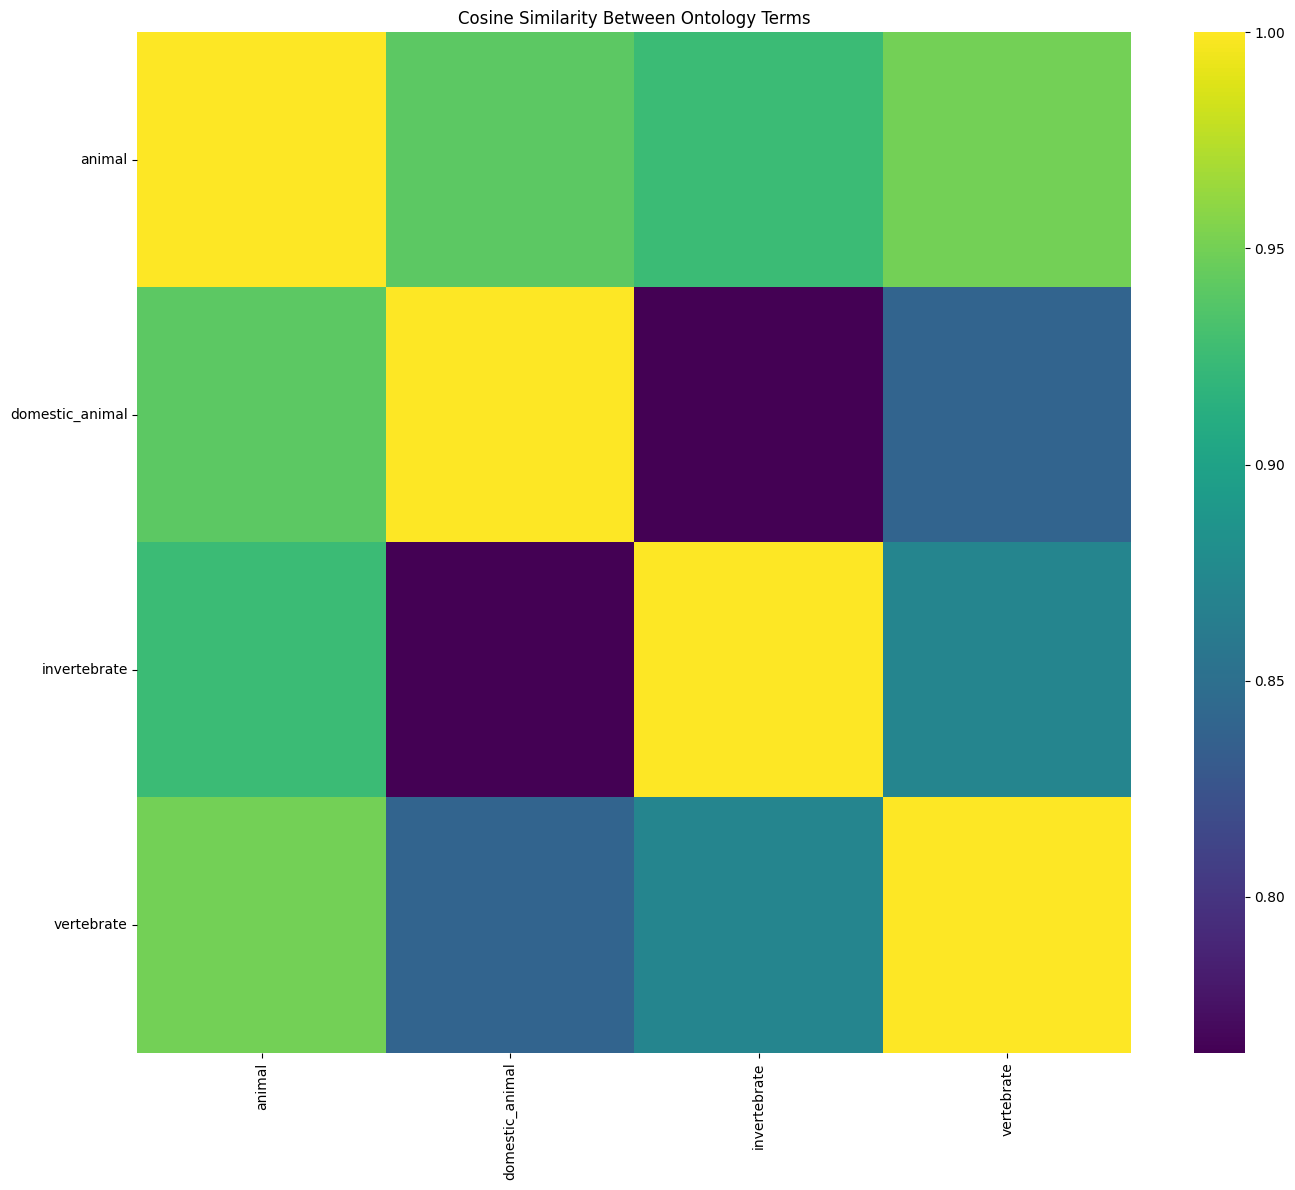

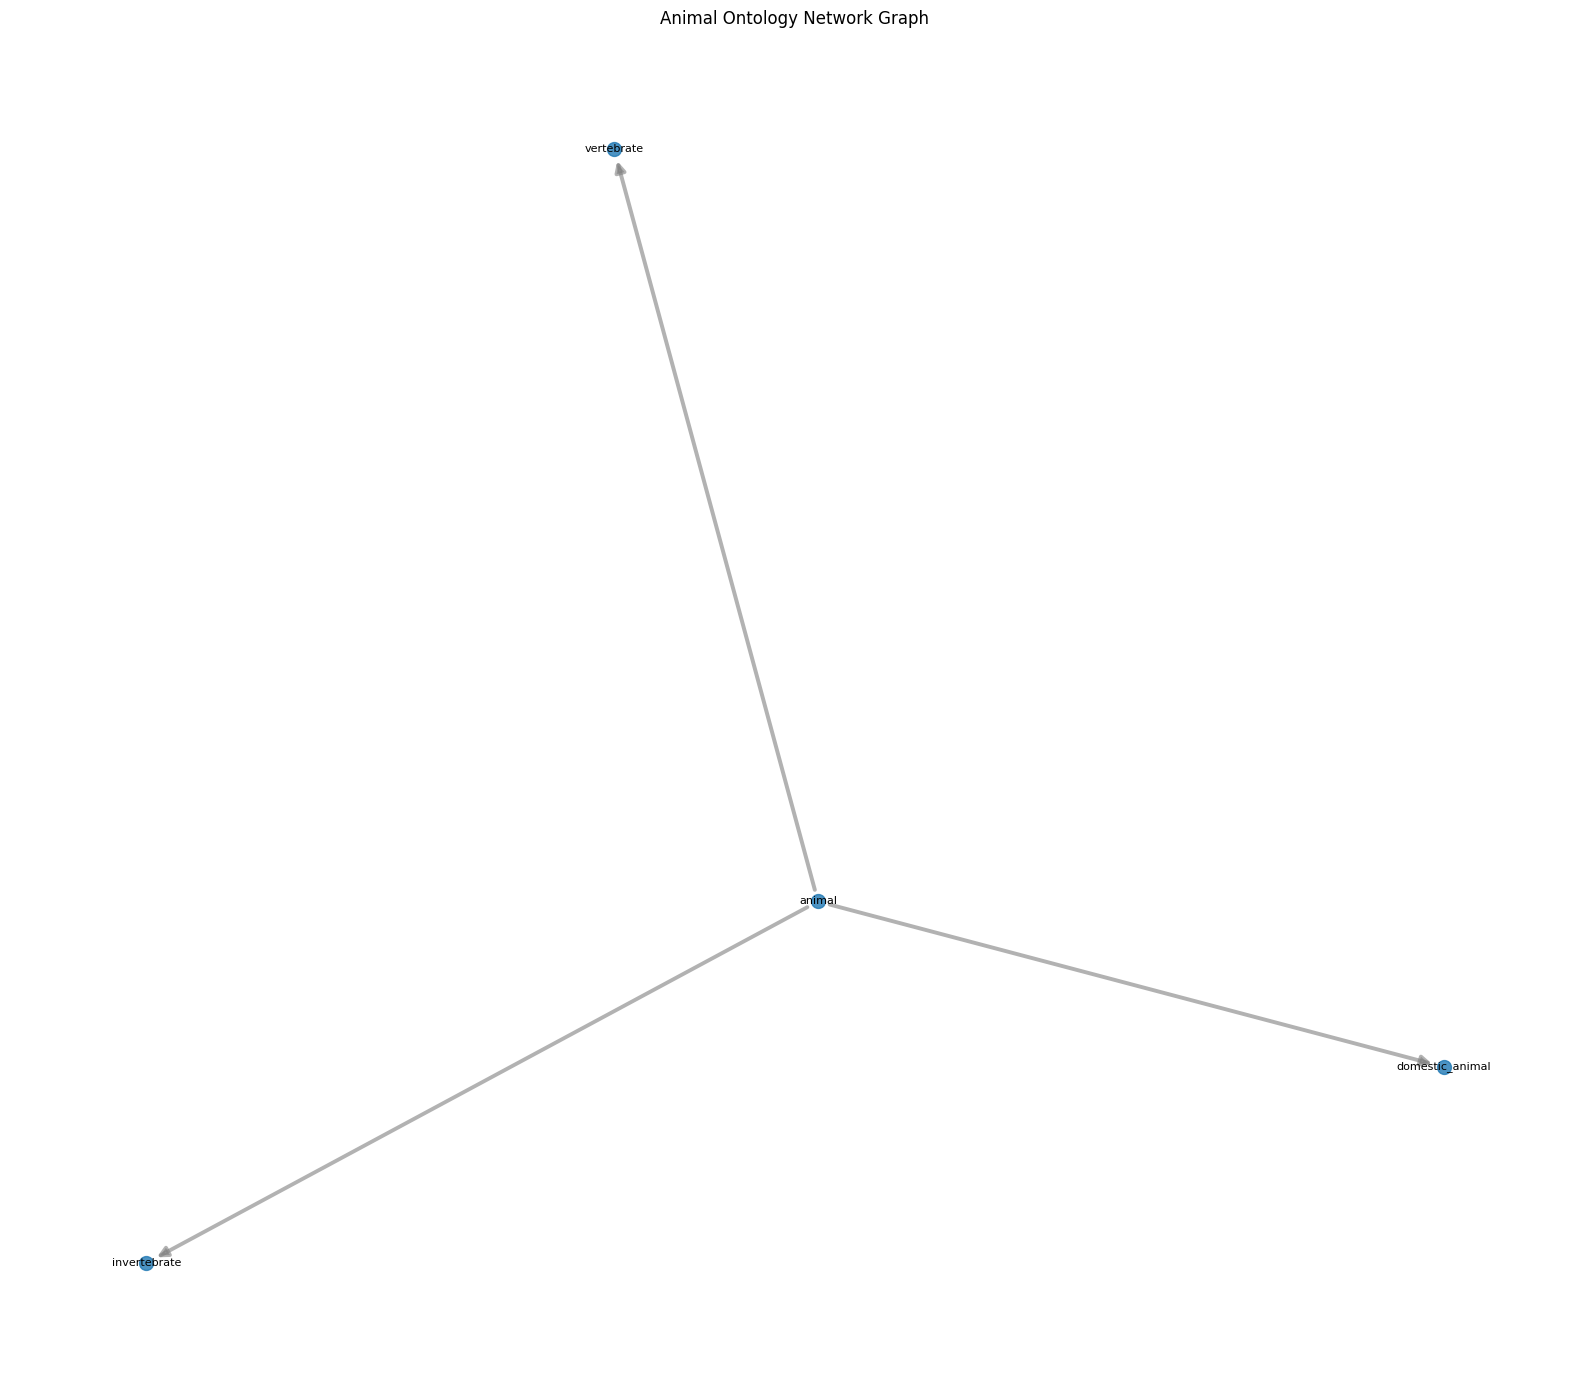

Hierarchy Alignment Analysis
Average Parent-Child Similarity: 0.9385
Median Parent-Child Similarity: 0.9407
Minimum Parent-Child Similarity: 0.9252
Maximum Parent-Child Similarity: 0.9495

Top 10 Strongest Parent-Child Relationships:
1. animal → vertebrate: 0.9495
2. animal → domestic_animal: 0.9407
3. animal → invertebrate: 0.9252

Bottom 10 Weakest Parent-Child Relationships:
1. animal → invertebrate: 0.9252
2. animal → domestic_animal: 0.9407
3. animal → vertebrate: 0.9495


In [59]:
hierarchy_analysis = perform_hierarchy_analysis(embedding_array, df)